# E-Commerce Pricing & Customer Behaviour Analysis

**Dataset:** UCI Online Retail Dataset (Kaggle)  
**Period:** December 2010 – December 2011  
**Records:** 541,909 transactions | 38 countries  

## Objectives
- Clean and validate raw transactional data
- Engineer meaningful features for analysis
- Analyse revenue trends, product performance, and geographic distribution
- Segment customers by revenue contribution
- Identify return patterns across products, countries, and customer segments

In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#1 Exploring Dataset

In [248]:
df =pd.read_csv("data.csv" ,encoding="latin-1") #loading dataset
df.head() #reading 1st five rows


#preview data
print(df.shape)
print(df.columns)

df.info() #Dataset Structure

#Missing Values
missing_values=df.isnull().sum() 
print("Missing Values" , missing_values)

#Statistical Summary
print("Numerical Summary" ,df.describe())#Numerical Summary
print("Categorical Summary",df.describe(include='str')) #Categorical Summary


(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
Missing Values InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Numerical Summary             Quantity      UnitPrice   

DataSet Overview

The dataset contains transactional retail data including product purchases, quantities, pricing, and customer information. Each row represents a single transaction line item. This dataset allows analysis of sales performance, customer behavior, and product return patterns.

#2 Data Cleaning

In [249]:
#Percentage of missing values

total_rows=(df.shape[0])
Percentage_Missing =(missing_values/total_rows)*100
print("Missing Values Percentage" ,Percentage_Missing)

Missing Values Percentage InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


**Missing Value Strategy:**

- Description (0.27% missing) — Rows retained. Product is still identifiable via StockCode.
- CustomerID (24.93% missing) — Rows retained for product-level and country-level analysis. 
  Excluded only from customer-level analysis (segmentation, return behaviour) since a 
  customer cannot be identified without an ID.

#3 Duplicate Removal

In [250]:



#Total number of rows
old_shape =df.shape[0]
print("Total Rows Before",old_shape) 


#Number of duplicated rows
duplicated=(df.duplicated().sum())
print("Number of duplicated rows" ,duplicated)

#Removing them
df=df.drop_duplicates()

#Number of rows after removing duplicated rows
new_shape =df.shape[0]
print("Number of rows after removal" ,new_shape)


#Number of rows removed
rows_removed=(old_shape - new_shape)
print("Total rows removed",rows_removed)



Total Rows Before 541909
Number of duplicated rows 5268
Number of rows after removal 536641
Total rows removed 5268


#4 Anamaly Detection (Quantity and UnitPrice)

In [251]:

#Minimum negative value of Quantity
print(df["Quantity"].min())

#Minimum negative value of UnitPrice
print(df["UnitPrice"].min())

#Negative Quantity Rows
Negative_Quantity_rows=df[df["Quantity"] < 0]
counter_negative_quantity =Negative_Quantity_rows.shape[0]
print("Number of rows with negative Quantity Values" ,counter_negative_quantity)

#Negative UnitPrice Rows
Negative_UnitPrice_rows=df[df["UnitPrice"] < 0]
counter_negative_unitprice =Negative_UnitPrice_rows.shape[0]
print("Number of rows with negative UnitPrice Values" ,counter_negative_unitprice)
df.shape[0]

-80995
-11062.06
Number of rows with negative Quantity Values 10587
Number of rows with negative UnitPrice Values 2


536641

Return Transaction Insight
Negative quantities in the dataset indicate product returns. Identifying and separating these transactions allows accurate measurement of both sales performance and return behavior.

#5 Removing invalid UnitPrice Values

In [252]:
#Rows before Removing invalid values
old_row_count=df.shape[0]
print("Rows before removing invalid unitprice values",old_row_count)

#Condition for removing invalid rows
df = df[ df["UnitPrice"] >= 0 ]

#Updated number of rows,after removing duplicated ones
new_row_count=df.shape[0]
print("Rows after removing invalid unitptice values",new_row_count)

#Total rows removed
rows_removed=(old_row_count - new_row_count)
print("Total rows removed",rows_removed)
df.shape[0]

Rows before removing invalid unitprice values 536641
Rows after removing invalid unitptice values 536639
Total rows removed 2


536639

#6 Dataset Validation

In [253]:
#Current Dataset Rows
print("Current Dataset row",df.shape[0])

#Remaining Duplicated
print("Number of duplicate rows remaining",df.duplicated().sum())
Remaining_negative_rows=df[df["UnitPrice"] < 0]
counter_remaining=Remaining_negative_rows.shape[0]
print("Number of remaining rows with negative UnitPrice Values" ,counter_remaining)

Current Dataset row 536639
Number of duplicate rows remaining 0
Number of remaining rows with negative UnitPrice Values 0


Data Quality Insight

Initial data inspection revealed the presence of missing values, duplicate records, and abnormal values such as negative quantities and invalid prices. These issues were addressed through data cleaning steps including duplicate removal and filtering invalid price entries to ensure accurate downstream analysis.

##Feature Engineering

In [254]:
df["Revenue"]=df["Quantity"] * df["UnitPrice"]
df[["Revenue","Quantity","UnitPrice"]].head()

,Revenue,Quantity,UnitPrice
0,15.30,6,2.55
1,20.34,6,3.39
2,22.00,8,2.75
3,20.34,6,3.39
4,20.34,6,3.39


#Revenue Metric
A new feature called Revenue was created to represent the financial value of each transaction. This metric allows consistent measurement of sales performance and financial impact across products, countries, and customers.

#1 Transaction Classification

In [255]:
conditions = [
    df["Quantity"] < 0, #Negative Quantity represent return transactions
    df["Quantity"] > 0,
    df["Quantity"] == 0
]

Labels =["Return" ,"Sale" , "Neutral"]
df["TransactionType"] = np.select(conditions,Labels,default="Neutral")
print("Total sales and total returns",df["TransactionType"].value_counts())

Total sales and total returns TransactionType
Sale      526052
Return     10587
Name: count, dtype: int64


Transaction Type Insight
Transactions were categorized into sales and returns based on quantity values. This classification enables separate analysis of revenue generation and return-related losses.

#2 Data Type Conversion For Time-Based Transactions

In [256]:
##Converting InvoiceDate from object to datetime format to enable time-based analysis.
df["InvoiceDate"].dtype
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].dtype

dtype('<M8[us]')

#3 Time-Based Variables

In [257]:
df["InvoiceYear"]=df["InvoiceDate"].dt.year
df["InvoiceMonth"]=df["InvoiceDate"].dt.month
df[["InvoiceDate" , "InvoiceMonth" , "InvoiceYear"]].head()

,InvoiceDate,InvoiceMonth,InvoiceYear
0,2010-12-01 08:26:00,12,2010
1,2010-12-01 08:26:00,12,2010
2,2010-12-01 08:26:00,12,2010
3,2010-12-01 08:26:00,12,2010
4,2010-12-01 08:26:00,12,2010


##Exploratory Data Analysis

In [258]:
#Monthly revenue Trend
Total_Revenue = df.groupby(["InvoiceYear", "InvoiceMonth"])["Revenue"].sum().reset_index()
print(Total_Revenue)


    InvoiceYear  InvoiceMonth      Revenue
0          2010            12   746723.610
1          2011             1   558448.560
2          2011             2   497026.410
3          2011             3   682013.980
4          2011             4   492367.841
5          2011             5   722094.100
6          2011             6   689977.230
7          2011             7   680156.991
8          2011             8   703510.580
9          2011             9  1017596.682
10         2011            10  1069368.230
11         2011            11  1456145.800
12         2011            12   432701.060


#Revenue Segmentation

In [259]:
#Revenue Based On Country
Revenue_Country =df.groupby(["Country"])["Revenue"].sum().reset_index()
Revenue_Country.sort_values(by='Revenue',ascending=False).head(10)

,Country,Revenue
36,United Kingdom,8189252.304
24,Netherlands,284661.540
10,EIRE,262993.380
14,Germany,221509.470
13,France,197317.110
0,Australia,137009.770
33,Switzerland,56363.050
31,Spain,54756.030
3,Belgium,40910.960
32,Sweden,36585.410


Revenue distribution across countries highlights the geographic markets contributing most to total sales. Identifying high-performing markets can help businesses prioritize expansion and marketing efforts.

In [260]:
#Return Ratio in each country
returns_df=df[ df["Revenue"] < 0 ]
Country_returns=returns_df.groupby(["Country"])["Revenue"].sum().reset_index()
Country_returns.sort_values(by='Revenue',ascending=True).head(10)

,Country,Revenue
29,United Kingdom,-812491.79
8,EIRE,-20147.14
11,France,-12308.26
24,Singapore,-12158.90
12,Germany,-7168.93
25,Spain,-6802.53
14,Hong Kong,-5574.76
22,Portugal,-4380.08
17,Japan,-2075.75
28,USA,-1849.47


In [261]:
return_ratio_of_each_country=pd.merge(Revenue_Country , Country_returns , on="Country" , how='outer')

return_ratio_of_each_country.fillna(0,inplace=True)
return_ratio_of_each_country = return_ratio_of_each_country.rename(
    columns={
        "Revenue_x": "Total_Revenue",
        "Revenue_y": "Return_Revenue"
    }
)

return_ratio_of_each_country["Return_Ratio"] =(
    abs(return_ratio_of_each_country["Return_Revenue"])  / return_ratio_of_each_country["Total_Revenue"]
)
return_ratio_of_each_country.sort_values(by="Return_Ratio",ascending=False).head

<bound method NDFrame.head of                  Country  Total_Revenue  Return_Revenue  Return_Ratio
30             Singapore       9120.390       -12158.90      1.333156
34                   USA       1730.920        -1849.47      1.068490
16             Hong Kong       9908.240        -5574.76      0.562639
2                Bahrain        548.400         -205.74      0.375164
8         Czech Republic        707.720         -119.02      0.168174
27              Portugal      29302.970        -4380.08      0.149476
31                 Spain      54756.030        -6802.53      0.124233
29          Saudi Arabia        131.170          -14.75      0.112449
36        United Kingdom    8189252.304      -812491.79      0.099214
23                 Malta       2505.470         -220.12      0.087856
10                  EIRE     262993.380       -20147.14      0.076607
13                France     197317.110       -12308.26      0.062378
20                 Japan      35340.620        -2075.75     

#True Return Ration by Each Country

In [262]:
# Step 1: Filter only positive revenue (gross sales)
sales_df = df[df["Revenue"] > 0]

# Step 2: Calculate Sales Revenue by Country
Sales_Revenue_Country = (sales_df.groupby("Country")["Revenue"].sum().reset_index())

# Step 3: Merge Sales Revenue with Return Revenue
return_ratio_country = pd.merge(Sales_Revenue_Country,Country_returns,on="Country",how="outer")

# Step 4: Rename columns for clarity
return_ratio_country = return_ratio_country.rename(
columns={
        "Revenue_x": "Sales_Revenue",
        "Revenue_y": "Return_Revenue"
    }
)

# Step 5: Replace missing return values with 0
return_ratio_country["Return_Revenue"] = (return_ratio_country["Return_Revenue"].fillna(0))

# Step 6: Calculate True Return Ratio
return_ratio_country["Return_Ratio"] = (abs(return_ratio_country["Return_Revenue"]) /return_ratio_country["Sales_Revenue"])

# Step 7: Sort and display top 10 countries with highest return ratio
return_ratio_country.sort_values(by="Return_Ratio",ascending=False)

return_ratio_country.head(10)


,Country,Sales_Revenue,Return_Revenue,Return_Ratio
0,Australia,138453.81,-1444.04,0.010430
1,Austria,10198.68,-44.36,0.004350
2,Bahrain,754.14,-205.74,0.272814
3,Belgium,41196.34,-285.38,0.006927
4,Brazil,1143.60,0.00,0.000000
5,Canada,3666.38,0.00,0.000000
6,Channel Islands,20440.54,-364.15,0.017815
7,Cyprus,13502.85,-644.09,0.047700
8,Czech Republic,826.74,-119.02,0.143963
9,Denmark,18955.34,-187.20,0.009876


Return ratios vary across countries, indicating potential differences in customer satisfaction, logistics performance, or product suitability for certain markets

##Product Analysis

#1 Top Product By Revenue

In [263]:
# Calculating revenue per product
Product_Revenue = ( df.groupby(["StockCode", "Description"])["Revenue"].sum().reset_index())

# Remove negative or zero revenue
Product_Revenue = Product_Revenue[Product_Revenue["Revenue"] > 0]

# Operational keywords to exclude
keywords = ["postage", "manual", "post", "adjustment", "fee", "bank charges"]

# Remove rows containing operational keywords
mask = Product_Revenue["Description"].str.contains("|".join(keywords), case=False, na=False)
Product_Revenue = Product_Revenue[~mask]

# Top 10 products by revenue
top_products = Product_Revenue.sort_values(by="Revenue", ascending=False).head(10)
(top_products)

,StockCode,Description,Revenue
1554,22423,REGENCY CAKESTAND 3 TIER,164459.49
3295,47566,PARTY BUNTING,98243.88
4223,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97659.94
4197,85099B,JUMBO BAG RED RETROSPOT,92175.79
2344,23084,RABBIT NIGHT LIGHT,66661.63
1207,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
3956,84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42
3525,79321,CHILLI LIGHTS,53746.66
2631,23298,SPOTTY BUNTING,42030.67
1521,22386,JUMBO BAG PINK POLKADOT,41584.43


High-revenue products are primarily decorative and gift-related items, suggesting strong demand for home décor and novelty products. These products contribute significantly to the overall profitability of the retail business.

##Business Insight
Decorative/home items dominate top revenue

Party and gift-oriented products appear frequently

Strong seasonal / festive potential (e.g., Christmas paper chain kit)


#2 Top Product By Quantity

In [264]:
# Calculating revenue per product
Product_Quantity = ( df.groupby(["StockCode", "Description"])["Quantity"].sum().reset_index())

# Remove negative or zero revenue
Product_Quantity = Product_Quantity[Product_Quantity["Quantity"] > 0]

# Operational keywords to exclude
keywords = ["postage", "manual", "post", "adjustment", "fee", "bank charges"]

# Remove rows containing operational keywords
mask = Product_Quantity["Description"].str.contains("|".join(keywords), case=False, na=False)
Product_Quantity = Product_Quantity[~mask]

# Top 10 products by revenue
top_selling = Product_Quantity.sort_values(by="Quantity", ascending=False).head(10)
(top_selling)


,StockCode,Description,Quantity
3617,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751
4197,85099B,JUMBO BAG RED RETROSPOT,47260
1333,22197,POPCORN HOLDER,36322
3956,84879,ASSORTED COLOUR BIRD ORNAMENT,36282
531,21212,PACK OF 72 RETROSPOT CAKE CASES,36016
4223,85123A,WHITE HANGING HEART T-LIGHT HOLDER,35006
2344,23084,RABBIT NIGHT LIGHT,30631
1630,22492,MINI PAINT SET VINTAGE,26437
1775,22616,PACK OF 12 LONDON TISSUES,26299
1122,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24719


Products with high sales volume may differ from those generating the most revenue. High-volume items are often lower-priced products purchased frequently by customers.

#Product Return Revenue

In [265]:
#Filter returns (Quantity < 0)
returns_df = df[df["Quantity"] < 0]

Product_Return_Revenue = ( returns_df.groupby(["StockCode", "Description"])["Revenue"].sum().reset_index())

#Remove operational keywords
operational_keywords = ["POSTAGE", "DOTCOM", "CARRIAGE", "BANK CHARGES","ADJUST", "AMAZON", "MANUAL", "FEE" ,"DISCOUNT" ,"COMISSION"]

pattern = "|".join(operational_keywords)

Product_Return_Revenue = Product_Return_Revenue[ ~Product_Return_Revenue["Description"].str.contains(pattern, case=False, na=False)]

Product_Return_Revenue = Product_Return_Revenue.sort_values(by="Revenue", ascending=True).head(10)
(Product_Return_Revenue)

,StockCode,Description,Revenue
1792,23843,"PAPER CRAFT , LITTLE BIRDIE",-168469.60
1514,23166,MEDIUM CERAMIC TOP STORAGE JAR,-77479.64
877,22423,REGENCY CAKESTAND 3 TIER,-9697.05
2428,CRUK,CRUK Commission,-7933.43
2284,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-6624.30
175,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-6591.42
1466,23113,PANTRY CHOPPING BOARD,-4803.06
1903,48185,DOORMAT FAIRY CAKE,-4554.90
208,21175,GIN + TONIC DIET METAL SIGN,-3775.33
1880,47566B,TEA TIME PARTY BUNTING,-3692.95


Certain products generate significant return revenue, indicating potential issues such as product quality, customer expectations, or shipping damage.

##Products with Highest Return Frequency

In [266]:
Product_Return_Transactions = ( returns_df.groupby(["StockCode", "Description"])["InvoiceNo"].nunique().reset_index())

#Remove operational keywords
keywords = "POSTAGE|CARRIAGE|AMAZON|MANUAL|PACKING|ADJUST|FEE|CHECK|ADJUSTMENT|DISCOUNT"
mask = ~Product_Return_Transactions["Description"].str.contains(
    keywords, case=False, na=False
)

Product_Return_Transactions = Product_Return_Transactions[mask]
Product_Return_Transactions= Product_Return_Transactions.sort_values(by="InvoiceNo", ascending=False).head(10)
(Product_Return_Transactions)


,StockCode,Description,InvoiceNo
877,22423,REGENCY CAKESTAND 3 TIER,180
1336,22960,JAM MAKING SET WITH JARS,87
1131,22720,SET OF 3 CAKE TINS PANTRY DESIGN,73
1113,22699,ROSES REGENCY TEACUP AND SAUCER,54
233,21232,STRAWBERRY CERAMIC TRINKET BOX,52
1083,22666,RECIPE BOX PANTRY YELLOW DESIGN,47
2273,85099B,JUMBO BAG RED RETROSPOT,43
67,20725,LUNCH BAG RED RETROSPOT,43
2284,85123A,WHITE HANGING HEART T-LIGHT HOLDER,42
1111,22697,GREEN REGENCY TEACUP AND SAUCER,42


##Product Return Ratio

In [267]:
# Sales
sales = (df[df["Quantity"] > 0].groupby(["StockCode","Description"])["Revenue"].sum().reset_index().rename(columns={"Revenue":"Sales_Revenue"}))

# Returns
returns = (df[df["Quantity"] < 0].groupby(["StockCode","Description"])["Revenue"].sum().reset_index().rename(columns={"Revenue":"Return_Revenue"}))

# Remove operational keywords
keywords = ["POSTAGE","MANUAL","AMAZON","FEE","DISCOUNT","ADJUSTMENT"]

sales = sales[~sales["Description"].str.upper().str.contains("|".join(keywords), na=False)]
returns = returns[~returns["Description"].str.upper().str.contains("|".join(keywords), na=False)]

# Merge + clean
merged = sales.merge(returns, on=["StockCode","Description"], how="left")
merged["Return_Revenue"] = merged["Return_Revenue"].fillna(0)

# Filter high sales + return ratio
filtered = merged[merged["Sales_Revenue"] >= 5000]
filtered["Return_Ratio"] = abs(filtered["Return_Revenue"]) / filtered["Sales_Revenue"]

# Top 10
top10 = filtered.sort_values("Return_Ratio", ascending=False).head(10)

top10

,StockCode,Description,Sales_Revenue,Return_Revenue,Return_Ratio
2727,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,-168469.60,1.000000
2179,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,-77479.64,0.948333
2113,23113,PANTRY CHOPPING BOARD,5868.50,-4803.06,0.818448
392,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,18056.28,-6591.42,0.365049
2945,47566B,TEA TIME PARTY BUNTING,11275.27,-3692.95,0.327527
1239,22273,FELTCRAFT DOLL MOLLY,12001.59,-3512.65,0.292682
1164,22191,IVORY DINER WALL CLOCK,11911.65,-2653.70,0.222782
1607,22655,VINTAGE RED KITCHEN CABINET,8125.00,-1730.50,0.212985
2981,48185,DOORMAT FAIRY CAKE,23872.91,-4554.90,0.190798
3017,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,17069.70,-3246.16,0.190171


Return ratio analysis highlights products where a large proportion of sold items are returned. High return ratios represent potential revenue leakage and operational inefficiencies.


##Customer Behaviour Analysis

#1 Top 10 Customers

In [268]:
# Step 1: Filter only positive revenue (gross sales)
sales_df = df[df["Quantity"] > 0]
Customer_Revenue = sales_df.groupby(["CustomerID"]).agg({"Revenue": "sum", "InvoiceNo": "nunique", "Quantity": "sum"}).reset_index()
Customer_Revenue = Customer_Revenue.rename(columns={"Revenue": "Total_Revenue", "InvoiceNo": "Unique_Transactions", "Quantity": "Total_Quantity"})

Top10_Customers =Customer_Revenue.sort_values(by="Total_Revenue", ascending=False).head(10)
Top10_Customers

,CustomerID,Total_Revenue,Unique_Transactions,Total_Quantity
1690,14646.0,280206.02,74,197491
4202,18102.0,259657.30,60,64124
3729,17450.0,194390.79,46,69973
3009,16446.0,168472.50,2,80997
1880,14911.0,143711.17,201,80490
55,12415.0,124914.53,21,77670
1334,14156.0,117210.08,55,57768
3772,17511.0,91062.38,31,64549
2703,16029.0,80850.84,63,40108
0,12346.0,77183.60,1,74215


A small group of customers contributes a disproportionately large share of total revenue. These high-value customers are critical for business performance and should be targeted with retention strategies.

#2 Customer Revenue Concentration

In [269]:
#Top 10 customers by revenue
Top10_Customers =Customer_Revenue.sort_values(by="Total_Revenue", ascending=False).head(10)

#Total Revenue Generated by top 10 customers
Top10_Revenue =Top10_Customers["Total_Revenue"].sum()

# Total revenue generated by all customers
Total_Revenue_All = Customer_Revenue["Total_Revenue"].sum()
Top10_Revenue_Percentage = (Top10_Revenue / Total_Revenue_All) * 100

print(f"{Top10_Revenue_Percentage:.2f}%")

#Top 10 customers contribute ~17% of total revenue.

#This suggests that revenue is relatively diversified across the customer base.
#The business does not heavily rely on a small number of buyers, reducing
#revenue concentration risk and improving overall revenue stability.

17.30%


The top 10 customers contribute approximately 17% of total revenue, indicating that revenue is relatively well distributed across the customer base. This suggests a diversified customer structure and reduced dependency on a small number of buyers.

#3 Customer Return Behaviour

In [270]:
#Filter only return transactions AND remove NaN CustomerID
returns_df = df[(df["Quantity"] < 0) & (df["CustomerID"].notna())]

#Group by CustomerID and calculate total returned quantity and return revenue
Customer_Returns = returns_df.groupby("CustomerID").agg({"Quantity": "sum",  "Revenue": "sum"}).reset_index()

#Rename columns to meaningful names
Customer_Returns = Customer_Returns.rename(columns={"Quantity": "Total_Quantity_Returned","Revenue": "Total_Revenue_Returned"})

#Sort by return revenue descending and take top 10
Top10_Return_Customers = Customer_Returns.sort_values(by="Total_Revenue_Returned",ascending=True).head(10)

# Display top 10 return-generating customers
Top10_Return_Customers


#Customer Return Behaviour Insight

#A small number of customers generate extremely large return values.
#For example, Customer 16446 alone returned products worth £168K,
#indicating potential bulk order cancellations or wholesale return behaviour.

,CustomerID,Total_Quantity_Returned,Total_Revenue_Returned
1136,16446.0,-80995,-168469.60
0,12346.0,-74215,-77183.60
779,15098.0,-61,-39267.00
1039,16029.0,-6476,-27682.15
965,15749.0,-9014,-22998.40
136,12744.0,-7,-12158.90
736,14911.0,-3335,-11252.44
185,12931.0,-4627,-8593.15
60,12536.0,-151,-8495.01
497,14096.0,-17,-8043.88


#3 Customer Segmentation(Revenue Based)

In [271]:
Customer_Revenue = Customer_Revenue.sort_values(by="Total_Revenue", ascending=False)
Cummulative_Revenue = Customer_Revenue["Total_Revenue"].cumsum()

#Cummulative Revenue Percentage
Cummulative_Revenue_Percentage = Cummulative_Revenue / Total_Revenue_All

# Step 5: Add cumulative percentage to dataframe
Customer_Revenue["Cumulative_Percentage"] = Cummulative_Revenue_Percentage

# Step 6: Create new column
Customer_Revenue["Customer_Segment"] = ""

# Apply segmentation rules
Customer_Revenue.loc[Customer_Revenue["Cumulative_Percentage"] <= 0.20, "Customer_Segment"] = "High Value"

Customer_Revenue.loc[(Customer_Revenue["Cumulative_Percentage"] > 0.20) & 
(Customer_Revenue["Cumulative_Percentage"] <= 0.50), "Customer_Segment"] = "Medium Value"

Customer_Revenue.loc[Customer_Revenue["Cumulative_Percentage"] > 0.50, "Customer_Segment"] = "Low Value"


# Step 7: Count customers in each segment
Customer_Revenue["Customer_Segment"].value_counts()



Customer_Segment
Low Value       4129
Medium Value     197
High Value        13
Name: count, dtype: int64

Business Insight
Revenue-based customer segmentation reveals a highly skewed distribution where a very small number of customers contribute a significant portion of total revenue. This pattern is typical in retail businesses and highlights the importance of retaining high-value customers.

#4 Return Risk by Customer Segment

In [272]:

# STEP 1: Merge datasets on CustomerID
df = pd.merge(Customer_Revenue, Customer_Returns, on='CustomerID', how='left')

# STEP 2: Replace missing values with 0
df['Total_Revenue_Returned'] = df['Total_Revenue_Returned'].fillna(0)

# STEP 3: Calculate Return_Ratio
df['Return_Ratio'] = df['Total_Revenue_Returned'] / df['Total_Revenue']

# STEP 4 & 5: Group by Customer_Segment and calculate average return ratio
result = df.groupby('Customer_Segment')['Return_Ratio'].mean().reset_index()

print(result)

  Customer_Segment  Return_Ratio
0       High Value     -0.209141
1        Low Value     -0.039080
2     Medium Value     -0.041004


##Visualization


#1 Monthly Revenue Trend

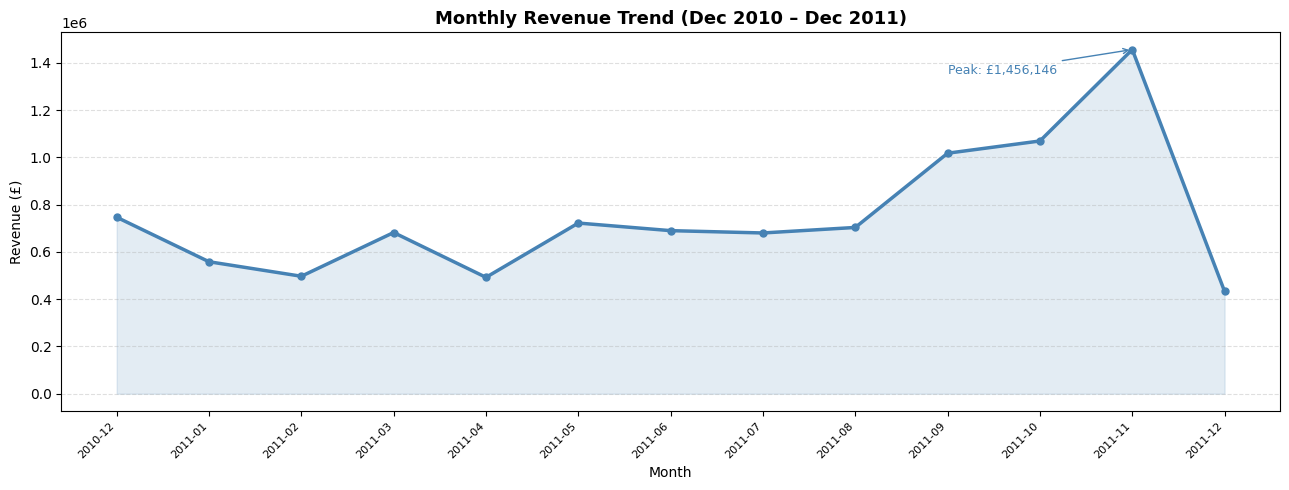

In [277]:
fig, ax = plt.subplots(figsize=(13, 5))

x = range(len(Total_Revenue))
ax.fill_between(x, Total_Revenue['Revenue'], alpha=0.15, color='steelblue')
ax.plot(x, Total_Revenue['Revenue'], color='steelblue', linewidth=2.5, marker='o', markersize=5)

ax.set_xticks(x)
ax.set_xticklabels(
    Total_Revenue['InvoiceYear'].astype(str) + '-' + Total_Revenue['InvoiceMonth'].astype(str).str.zfill(2),
    rotation=45, ha='right', fontsize=8
)

ax.set_title('Monthly Revenue Trend (Dec 2010 – Dec 2011)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
peak_idx = Total_Revenue['Revenue'].idxmax()
ax.annotate(
    f'Peak: £{Total_Revenue["Revenue"].iloc[peak_idx]:,.0f}',
    xy=(peak_idx, Total_Revenue['Revenue'].iloc[peak_idx]),
    xytext=(peak_idx - 2, Total_Revenue['Revenue'].iloc[peak_idx] * 0.93),
    fontsize=9, color='steelblue',
    arrowprops=dict(arrowstyle='->', color='steelblue')
)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Insight:** Revenue spikes sharply in Sep–Nov 2011, driven by Christmas gifting demand. 
December dip reflects partial-month data. Businesses should plan inventory and 
marketing campaigns ahead of Q4.

#2 Top 10 Products By Revenue

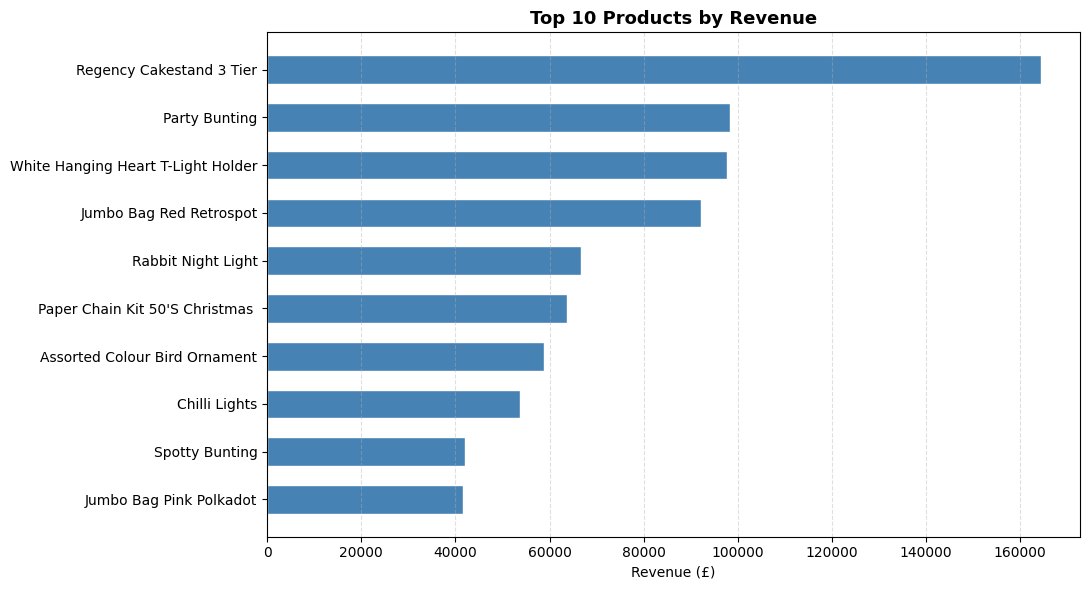

In [278]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    top_products['Description'].str.title(),
    top_products['Revenue'],
    color='steelblue', edgecolor='white', height=0.6
)

ax.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Insight:** Decorative and gift items dominate revenue. Regency Cakestand alone 
generates £164K — nearly double the second product. This suggests a premium gifting 
category that should be prioritized in marketing.

#3 Revenue By Country(Top 10)

C:\Users\athar\AppData\Local\Temp\ipykernel_2908\2890598895.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top10_countries['Country'], rotation=35, ha='right', fontsize=9)


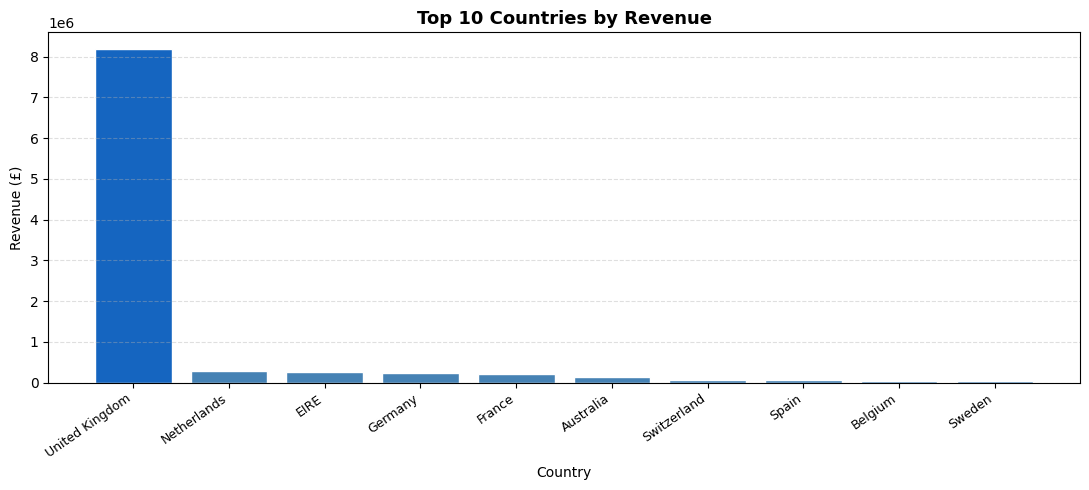

In [280]:
# Pehle sort karo revenue se
top10_countries = Revenue_Country.sort_values(by='Revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#1565C0' if c == 'United Kingdom' else 'steelblue' 
          for c in top10_countries['Country']]

ax.bar(
    top10_countries['Country'],
    top10_countries['Revenue'],
    color=colors, edgecolor='white'
)

ax.set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Revenue (£)')
ax.set_xticklabels(top10_countries['Country'], rotation=35, ha='right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Insight:** UK contributes ~83% of total revenue. Netherlands, EIRE, and Germany 
are the strongest international markets and represent expansion opportunities.

#4 Customer Segment Distribution

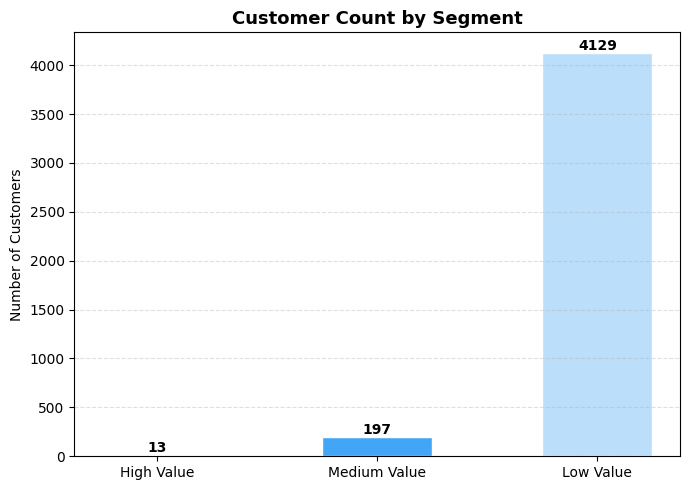

In [281]:
seg_order = ['High Value', 'Medium Value', 'Low Value']
seg_colors = ['#1565C0', '#42A5F5', '#BBDEFB']

seg_counts = Customer_Revenue['Customer_Segment'].value_counts().reindex(seg_order)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(seg_order, seg_counts.values, color=seg_colors, edgecolor='white', width=0.5)

# Value labels upar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(bar.get_height()),
        ha='center', fontsize=10, fontweight='bold'
    )

ax.set_title('Customer Count by Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Insight:** Only 13 High Value customers drive 20% of all customer revenue. 
Retaining these customers should be the top business priority.

#5 Return Ratio By Customer Segments

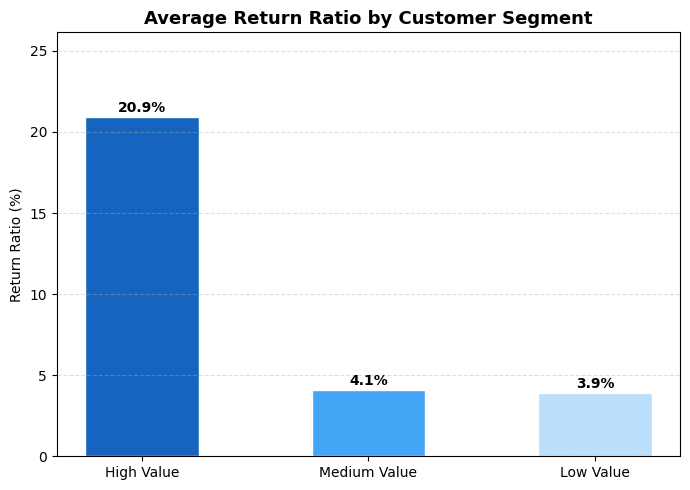

In [282]:
seg_order = ['High Value', 'Medium Value', 'Low Value']
seg_colors = ['#1565C0', '#42A5F5', '#BBDEFB']

ratios = [abs(result[result['Customer_Segment'] == s]['Return_Ratio'].values[0]) * 100 
          for s in seg_order]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(seg_order, ratios, color=seg_colors, edgecolor='white', width=0.5)

for bar, ratio in zip(bars, ratios):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{ratio:.1f}%',
        ha='center', fontsize=10, fontweight='bold'
    )

ax.set_title('Average Return Ratio by Customer Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Return Ratio (%)')
ax.set_ylim(0, max(ratios) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Insight:** High Value customers return 20.9% of revenue — 5x more than other segments. 
This likely reflects bulk order cancellations. Investigate these customers individually.

## Key Findings Summary

| # | Finding | Business Implication |
|---|---------|----------------------|
| 1 | Revenue peaks in Sep–Nov 2011 | Plan inventory and marketing ahead of Q4 |
| 2 | UK contributes ~83% of total revenue | International markets are underserved growth opportunities |
| 3 | 13 High Value customers drive 20% of revenue | Build a VIP retention programme |
| 4 | High Value customers have 20.9% return ratio | Investigate bulk order cancellation behaviour |
| 5 | Decorative/gift products dominate revenue | Prioritize premium gift range in marketing |
| 6 | Negative quantities = returns (10,587 transactions) | Separate return analysis is essential for accurate revenue reporting |